# Hurricane Recovery Potential - Key Visualizations

This notebook generates the main figures from the hurricane recovery study:

1. **Three-Panel Maps**: Annual, Median Event, and Maximum Event metrics
2. **Recovery Drivers Scatterplots**: Comparing annual vs median vs max perspectives
3. **Skewness Spatial Map**: Tail dominance analysis
4. **Quadrant Analysis**: Absolute vs normalized comparisons

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from pathlib import Path
import json
from scipy.stats import pearsonr
from scipy.io import loadmat
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration and Helper Functions

In [2]:
# Configuration
RECOVERY_WEIGHTS = {
    'DS1': 1.0,
    'DS2': 1.0,
    'DS3': 3.0,
    'DS4': 6.0
}

COASTAL_STATE_FIPS = ['01', '09', '10', '12', '13', '22', '23', '24', '25', '28',
                      '33', '34', '36', '37', '42', '44', '45', '48', '51']

DEFAULT_FREQ = 0.00067334  # events/year

# Paths
DATA_DIR = Path('..', 'data')
OUTPUT_DIR = Path('..', 'analysis_output')
IMPACTS_DIR = Path('..', 'impacts_out')

print("Configuration set!")

Configuration set!


## 3. Load Data

### Load hazard data

Create a 3-panel map showing maximum wind, rainfall, and storm surge intensities across coastal counties.

In [3]:
hazard_dir = DATA_DIR / "hazard"

# Load wind data
wind_data = loadmat(hazard_dir / "maxwindmat_ncep_reanal.mat")
maxwindmat = wind_data["maxwindmat"]  # Shape: (events, counties)
print(f"Wind data shape: {maxwindmat.shape}")
print(f"Wind range: {maxwindmat.min():.2f} - {maxwindmat.max():.2f} m/s")

# Load rain data
rain_data = loadmat(hazard_dir / "ptot_rain_county_ncep_reanal.mat")
ptot_mat = rain_data["ptot_mat"]  # Shape might be (counties, events)
print(f"\nRain data shape: {ptot_mat.shape}")
print(f"Rain range: {ptot_mat.min():.2f} - {ptot_mat.max():.2f} mm")

# Load storm surge data
surge_data = loadmat(hazard_dir / "maxelev_coastcounty_ncep_reanal.mat")
# Use MHHW-adjusted surge if available
if "scounty_mhhw" in surge_data:
    scounty = surge_data["scounty_mhhw"]
    print("\nUsing MHHW-adjusted storm surge")
else:
    scounty = surge_data["scounty"]
    print("\nUsing raw storm surge")
print(f"Surge data shape: {scounty.shape}")
print(f"Surge range: {scounty.min():.2f} - {scounty.max():.2f} m")

Wind data shape: (5018, 3220)
Wind range: 0.00 - 84.45 m/s

Rain data shape: (3220, 5018)
Rain range: 0.00 - 1432.36 mm

Using MHHW-adjusted storm surge
Surge data shape: (3220, 5018)
Surge range: -0.57 - 10.93 m


In [4]:
# Transpose rain and surge if needed to match wind dimensions (events x counties)
if ptot_mat.shape[0] != maxwindmat.shape[0]:
    ptot_mat = ptot_mat.T
    print(f"Transposed rain data to: {ptot_mat.shape}")

if scounty.shape[0] != maxwindmat.shape[0]:
    scounty = scounty.T
    print(f"Transposed surge data to: {scounty.shape}")

# Verify all have same shape
assert maxwindmat.shape == ptot_mat.shape == scounty.shape, "Hazard arrays must have same shape"
print(f"\nAll hazard arrays aligned: {maxwindmat.shape} (events x counties)")

Transposed rain data to: (5018, 3220)
Transposed surge data to: (5018, 3220)

All hazard arrays aligned: (5018, 3220) (events x counties)


In [5]:
# Compute maximum hazard values per county (max across all events)
max_wind_per_county = maxwindmat.max(axis=0)
max_rain_per_county = ptot_mat.max(axis=0)
max_surge_per_county = scounty.max(axis=0)

hazard_df = pd.DataFrame({
    'county_index': range(len(max_wind_per_county)),
    'MaxWind_ms': max_wind_per_county,
    'MaxRain_mm': max_rain_per_county,
    'MaxSurge_m': max_surge_per_county,
})

print(f"Created hazard DataFrame with {len(hazard_df)} counties")
hazard_df.head()

Created hazard DataFrame with 3220 counties


,county_index,MaxWind_ms,MaxRain_mm,MaxSurge_m
0,0,73.881486,502.903792,3.390770
1,1,67.103668,390.749873,2.771400
2,2,63.912341,419.516782,3.971260
3,3,58.927643,435.498477,3.941923
4,4,59.323959,471.912977,4.437827


In [6]:
# Load county reference mapping
county_ref = pd.read_csv(DATA_DIR / "county_region.csv")
print(f"Loaded county reference with {len(county_ref)} counties")

# Create GEOID from stcode and ccode
county_ref['GEOID'] = county_ref['stcode'].astype(str).str.zfill(2) + county_ref['ccode'].astype(str).str.zfill(3)

# Merge hazard data with county reference
hazard_with_geoid = hazard_df.merge(
    county_ref[['county_index', 'GEOID']], 
    on='county_index', 
    how='left'
)

print(f"Hazard data with GEOID: {len(hazard_with_geoid)} counties")
print(f"Counties with GEOID: {hazard_with_geoid['GEOID'].notna().sum()}")

Loaded county reference with 3220 counties
Hazard data with GEOID: 3220 counties
Counties with GEOID: 3220


In [7]:
# Note: coastal_counties will be loaded in section 3
# We'll merge hazard data with coastal counties after they are loaded
print("Hazard data ready to merge with coastal counties (see section below)")

Hazard data ready to merge with coastal counties (see section below)


### Load impact, recovery, and construction capacity data incl. county shapefiles

In [8]:
# Load per-event impact data
print("Loading per-event impact data...")
by_event_dir = IMPACTS_DIR / "by_event" / "scaled"
event_files = sorted(by_event_dir.glob("*_scaled.csv"))

all_events = []
for f in event_files:
    df = pd.read_csv(f)
    df['event_name'] = f.stem.replace('_scaled', '')
    all_events.append(df)

events_df = pd.concat(all_events, ignore_index=True)
events_df['fips'] = events_df['fips'].astype(str).str.zfill(5)

print(f"Loaded {len(events_df):,} county-event records")
print(f"Unique events: {events_df['event_name'].nunique()}")
print(f"Unique counties: {events_df['fips'].nunique()}")

Loading per-event impact data...
Loaded 35,438 county-event records
Unique events: 2004
Unique counties: 808


In [9]:
# Load recovery potential data
print("\nLoading recovery potential data...")
recovery_dir = DATA_DIR / "recovery_potential_per_scenario"
recovery_files = list(recovery_dir.glob("*_scaled_recovery_potential.json"))

all_recovery = []
for idx, f in enumerate(recovery_files):
    if (idx + 1) % 500 == 0:
        print(f"  Loaded {idx + 1}/{len(recovery_files)} files...")
    
    with open(f, 'r') as file:
        data = json.load(file)
        df = pd.DataFrame(data)
        all_recovery.append(df)

recovery_df = pd.concat(all_recovery, ignore_index=True)
recovery_df['fips'] = recovery_df['fips'].astype(str).str.zfill(5)
recovery_df['recovery_potential [months]'] = (
    recovery_df['recovery_potential [months]'].replace([np.inf, -np.inf], np.nan)
)

print(f"Loaded {len(recovery_df):,} recovery records")


Loading recovery potential data...
  Loaded 500/2004 files...
  Loaded 1000/2004 files...
  Loaded 1500/2004 files...
  Loaded 2000/2004 files...
Loaded 35,438 recovery records


In [10]:
# Load construction capacity data
print("\nLoading construction capacity data...")
permits_file = DATA_DIR / "selected_states_counties_with_permits.csv"
permits_df = pd.read_csv(permits_file)
print(f"DEBUG: Read {len(permits_df)} rows from {permits_file.name}")

# Column is 'FIPS' (uppercase) and capacity needs to be computed from building permits
permits_df['fips'] = permits_df['FIPS'].astype(str).str.zfill(5)
permits_df['construction_capacity'] = permits_df['Average_Building_Permits(12 months)'] / 12  # monthly capacity

capacity_df = permits_df[['fips', 'construction_capacity']].copy()
print(f"Loaded capacity data for {len(capacity_df)} counties")
print(f"Capacity range: {capacity_df['construction_capacity'].min():.2f} - {capacity_df['construction_capacity'].max():.2f} permits/month")
print(f"Sample FIPS codes: {capacity_df['fips'].head(10).tolist()}")


Loading construction capacity data...
DEBUG: Read 1203 rows from selected_states_counties_with_permits.csv
Loaded capacity data for 1203 counties
Capacity range: 0.00 - 207.52 permits/month
Sample FIPS codes: ['01001', '01003', '01005', '01007', '01009', '01011', '01013', '01015', '01017', '01019']


In [11]:
# Load spatial data (county boundaries)
print("\nLoading county boundaries...")
counties = gpd.read_file(DATA_DIR / 'US_counties.shp')
coastal_counties = counties[counties['STATEFP'].isin(COASTAL_STATE_FIPS)].copy()
coastal_counties['GEOID'] = coastal_counties['STATEFP'] + coastal_counties['COUNTYFP']
coastal_counties['GEOID'] = coastal_counties['GEOID'].astype(str).str.zfill(5)

print(f"Loaded {len(coastal_counties)} coastal counties")


Loading county boundaries...
Loaded 1202 coastal counties


### Merge Hazard Data with Coastal Counties

In [12]:
# Merge hazard data with coastal county geometries
merged_hazard = coastal_counties.merge(hazard_with_geoid, on='GEOID', how='left')

print(f"Merged {len(merged_hazard)} counties")
print(f"Counties with wind data: {merged_hazard['MaxWind_ms'].notna().sum()}")
print(f"Counties with rain data: {merged_hazard['MaxRain_mm'].notna().sum()}")
print(f"Counties with surge data: {(merged_hazard['MaxSurge_m'] > 0).sum()}")

Merged 1202 counties
Counties with wind data: 1202
Counties with rain data: 1202
Counties with surge data: 174


## Figure: 3-Panel Hazard Overview Map

Creating hazard overview map...
✓ Saved: na_coast_hazard_overview.png


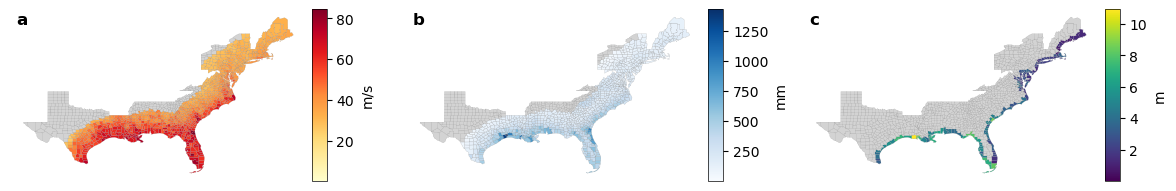

In [13]:
print("Creating hazard overview map...")

# Create 3 side-by-side subplots for hazard intensities
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

hazard_metrics = [
    ("MaxWind_ms", "YlOrRd", "Maximum Wind Speed", "m/s"),
    ("MaxRain_mm", "Blues", "Maximum Rainfall", "mm"),
    ("MaxSurge_m", "viridis", "Maximum Storm Surge", "m")
]

subplot_labels = ['a', 'b', 'c']

# Create a copy of merged_hazard and replace zeros with NaN for plotting
merged_hazard_plot = merged_hazard.copy()
for column, _, _, _ in hazard_metrics:
    merged_hazard_plot.loc[merged_hazard_plot[column] <= 0, column] = np.nan

for idx, (ax, (column, cmap, title, unit)) in enumerate(zip(axes, hazard_metrics)):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    # Get valid data for setting vmin
    data_positive = merged_hazard_plot[column].dropna()
    
    # Set vmin to a very small value above zero
    if not data_positive.empty:
        vmin = data_positive.min() * 0.01  # Start colormap at 1% of minimum positive value
        vmax = data_positive.max()
    else:
        vmin = None
        vmax = None

    # Plot with linear scale, zeros (now NaN) will show as white
    merged_hazard_plot.plot(
        column=column,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidth=0.1,
        edgecolor="0.5",
        legend=True,
        ax=ax,
        cax=cax,
        legend_kwds={'label': title},
        missing_kwds={
            "color": "lightgray",
            "label": "No data / Zero",
            "edgecolor": "0.5"
        }
    )

    # Axis (no title)
    ax.axis("off")
    
    # Add subplot label
    ax.text(0.02, 0.98, subplot_labels[idx], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

    # Set colorbar label and tick font size
    cax.set_ylabel(unit, fontsize=10)
    cax.tick_params(labelsize=10)

    # Set colorbar box edge to black
    for spine in cax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "na_coast_hazard_overview.png", dpi=300, bbox_inches="tight")
print("✓ Saved: na_coast_hazard_overview.png")
plt.show()
plt.close()

## Compute Metrics for Three-Panel Damage and Recovery Maps

In [14]:
# Calculate weighted damage for each event-county
print("Computing weighted damage...")
events_df['weighted_damage'] = (
    events_df['units_DS1_scaled'] * RECOVERY_WEIGHTS['DS1'] +
    events_df['units_DS2_scaled'] * RECOVERY_WEIGHTS['DS2'] +
    events_df['units_DS3_scaled'] * RECOVERY_WEIGHTS['DS3'] +
    events_df['units_DS4_scaled'] * RECOVERY_WEIGHTS['DS4']
)

# Compute Expected Annual Weighted Damage (EAD)
print("Computing annual metrics...")
ead_weighted = events_df.groupby('fips')['weighted_damage'].sum().reset_index()
ead_weighted['ead_weighted'] = ead_weighted['weighted_damage'] * DEFAULT_FREQ
ead_weighted = ead_weighted[['fips', 'ead_weighted']]

# Compute Expected Annual Recovery Potential (EARP)
earp = recovery_df.groupby('fips')['recovery_potential [months]'].sum().reset_index()
earp['earp_months_per_year'] = earp['recovery_potential [months]'] * DEFAULT_FREQ
earp = earp[['fips', 'earp_months_per_year']]

# Merge annual metrics
annual_metrics = ead_weighted.merge(earp, on='fips', how='inner')
annual_metrics = annual_metrics.merge(capacity_df, on='fips', how='inner')
annual_metrics = annual_metrics[
    (annual_metrics['ead_weighted'] > 0) &
    (annual_metrics['earp_months_per_year'] > 0) &
    (annual_metrics['construction_capacity'] > 0)
]

print(f"Annual metrics computed for {len(annual_metrics)} counties")

Computing weighted damage...
Computing annual metrics...
Annual metrics computed for 685 counties


In [15]:
# Compute Median Event metrics
print("\nComputing median event metrics...")

# Merge event damage and recovery data
recovery_renamed = recovery_df.rename(columns={'event': 'event_name'})
merged = events_df[['fips', 'event_name', 'weighted_damage']].merge(
    recovery_renamed[['fips', 'event_name', 'recovery_potential [months]']],
    on=['fips', 'event_name'],
    how='inner'
)

# Calculate medians per county
median_metrics = merged.groupby('fips').agg({
    'weighted_damage': 'median',
    'recovery_potential [months]': 'median'
}).reset_index()

median_metrics = median_metrics.rename(columns={
    'weighted_damage': 'median_weighted_damage',
    'recovery_potential [months]': 'median_recovery_months'
})

# Add capacity and filter
median_metrics = median_metrics.merge(capacity_df, on='fips', how='inner')
median_metrics = median_metrics[
    (median_metrics['median_weighted_damage'] > 0) &
    (median_metrics['median_recovery_months'] > 0) &
    (median_metrics['construction_capacity'] > 0)
]

print(f"Median metrics computed for {len(median_metrics)} counties")


Computing median event metrics...
Median metrics computed for 655 counties


In [16]:
# Compute Maximum Event metrics
print("\nComputing maximum event metrics...")

# Find index of max weighted damage event per county
idx_max = merged.groupby('fips')['weighted_damage'].idxmax()

# Extract max event data per county
max_metrics = merged.loc[idx_max.dropna()].reset_index(drop=True)
max_metrics = max_metrics.rename(columns={
    'weighted_damage': 'max_weighted_damage',
    'recovery_potential [months]': 'max_recovery_months'
})

# Add capacity and filter
max_metrics = max_metrics.merge(capacity_df, on='fips', how='inner')
max_metrics = max_metrics[
    (max_metrics['max_weighted_damage'] > 0) &
    (max_metrics['max_recovery_months'] > 0) &
    (max_metrics['construction_capacity'] > 0)
]

print(f"Max event metrics computed for {len(max_metrics)} counties")


Computing maximum event metrics...
Max event metrics computed for 685 counties


## Figure: Three-Panel Damage, Construction Capacity, Recovery Potential Maps

In [17]:
def create_3panel_map(coastal_counties, metrics_df, metric_cols, title_prefix, output_file):
    """Create 3-panel map with specified metrics."""
    
    # Merge metrics with spatial data
    merged = coastal_counties.merge(metrics_df, left_on='GEOID', right_on='fips', how='left')
    
    # Create plotting copy with zeros as NaN
    merged_plot = merged.copy()
    for col in metric_cols:
        merged_plot.loc[merged_plot[col] <= 0, col] = np.nan
    
    # Define titles based on metric type
    if 'ead_weighted' in metric_cols:
        damage_title = f'{title_prefix}\nWeighted Units Affected'
        damage_ylabel = 'affected units (weighted)'
        recovery_title = f'{title_prefix}\nRecovery Potential'
        recovery_ylabel = 'recovery potential'
    elif 'median' in metric_cols[0]:
        damage_title = f'{title_prefix}\nWeighted Damage'
        damage_ylabel = 'affected units (weighted)'
        recovery_title = f'{title_prefix}\nRecovery Time'
        recovery_ylabel = 'recovery potential'
    else:  # max
        damage_title = f'{title_prefix}\nWeighted Damage'
        damage_ylabel = 'affected units (weighted)'
        recovery_title = f'{title_prefix}\nRecovery Time'
        recovery_ylabel = 'recovery potential'
    
    # Define metrics for each panel
    metrics_config = [
        (metric_cols[0], 'cividis', damage_title, damage_ylabel),
        (metric_cols[1], 'Greens', f'{title_prefix}\nConstruction Capacity', 'permits/month'),
        (metric_cols[2], 'Purples_r', recovery_title, recovery_ylabel)
    ]
    
    # Subplot labels
    subplot_labels = ['a', 'b', 'c']
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = axes.flatten()
    
    for idx, (ax, (metric, cmap, title, ylabel)) in enumerate(zip(axes, metrics_config)):
        # Get valid data for this metric
        data_positive = merged_plot[metric].dropna()
        
        if not data_positive.empty and len(data_positive) > 0:
            vmin = data_positive.min()
            vmax = data_positive.max()
            
            if np.isfinite(vmin) and np.isfinite(vmax) and vmin > 0 and vmax > 0:
                log_vmin = vmin / 2
                norm = LogNorm(vmin=log_vmin, vmax=vmax)
            else:
                norm = None
        else:
            norm = None
        
        # Create divider for colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        
        # Plot
        merged_plot.plot(
            column=metric,
            cmap=cmap,
            norm=norm,
            linewidth=0.1,
            edgecolor="0.5",
            legend=True,
            ax=ax,
            cax=cax,
            missing_kwds={
                "color": "lightgrey",
                "label": "No data",
                "edgecolor": "0.5"
            }
        )
        
        # Axis (no title)
        ax.axis("off")
        
        # Add subplot label
        ax.text(0.02, 0.98, subplot_labels[idx], transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
        
        # Colorbar formatting
        if 'Recovery' in title or 'recovery' in ylabel:
            # Invert for recovery (higher = worse)
            cax.invert_yaxis()
            cax.yaxis.set_major_locator(NullLocator())
            cax.yaxis.set_minor_locator(NullLocator())
            cax.tick_params(which='both', left=False, right=False, labelleft=False)
            
            cax.text(1.5, 0.99, 'high', transform=cax.transAxes, 
                    fontsize=10, va='top', ha='left')
            cax.text(1.5, 0.01, 'low', transform=cax.transAxes, 
                    fontsize=10, va='bottom', ha='left')
            
            cax.set_ylabel(ylabel, fontsize=10)
        else:
            cax.set_ylabel(ylabel, fontsize=10)
            cax.tick_params(labelsize=10)
            cax.tick_params(which='minor', length=0)
        
        for spine in cax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    print(f"✓ Saved: {output_file}")
    plt.show()
    plt.close()


### Annual Expected Metrics

✓ Saved: ../analysis_output/annual_3panel.png


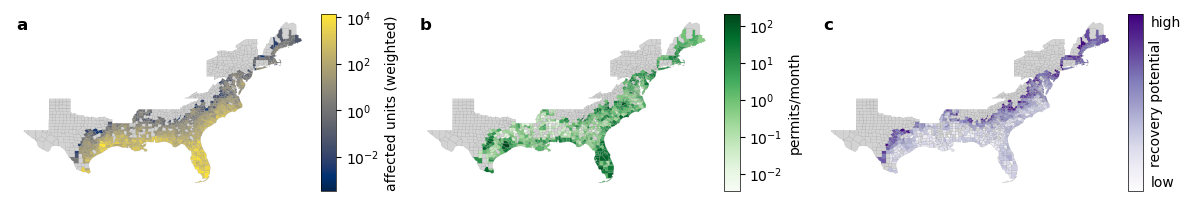

In [18]:
# Generate Annual 3-Panel Map
create_3panel_map(
    coastal_counties,
    annual_metrics,
    ['ead_weighted', 'construction_capacity', 'earp_months_per_year'],
    'Expected Annual',
    OUTPUT_DIR / "annual_3panel.png"
)

### Median Event Metrics

✓ Saved: ../analysis_output/median_event_3panel.png


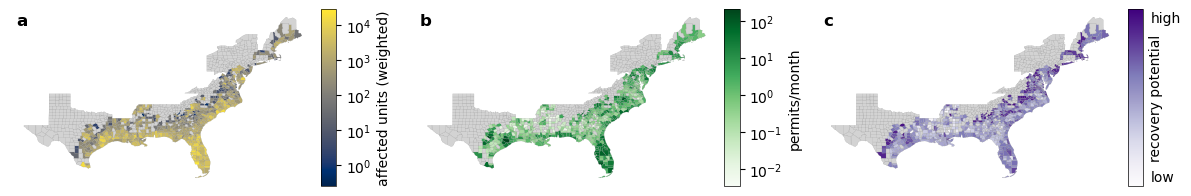

In [19]:
# Generate Median Event 3-Panel Map
create_3panel_map(
    coastal_counties,
    median_metrics,
    ['median_weighted_damage', 'construction_capacity', 'median_recovery_months'],
    'Median Event',
    OUTPUT_DIR / "median_event_3panel.png"
)

### Maximum Event Metrics

✓ Saved: ../analysis_output/max_event_3panel.png


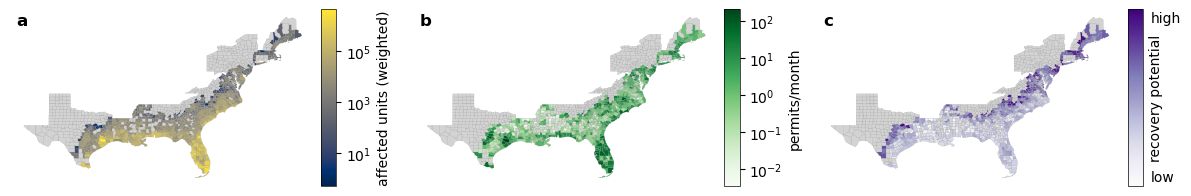

In [20]:
# Generate Maximum Event 3-Panel Map
create_3panel_map(
    coastal_counties,
    max_metrics,
    ['max_weighted_damage', 'construction_capacity', 'max_recovery_months'],
    'Maximum Event',
    OUTPUT_DIR / "max_event_3panel.png"
)

## Figure: Recovery Drivers Scatterplots

Creating recovery drivers scatterplot comparison...
✓ Saved: recovery_drivers_annual_vs_median_vs_max.png


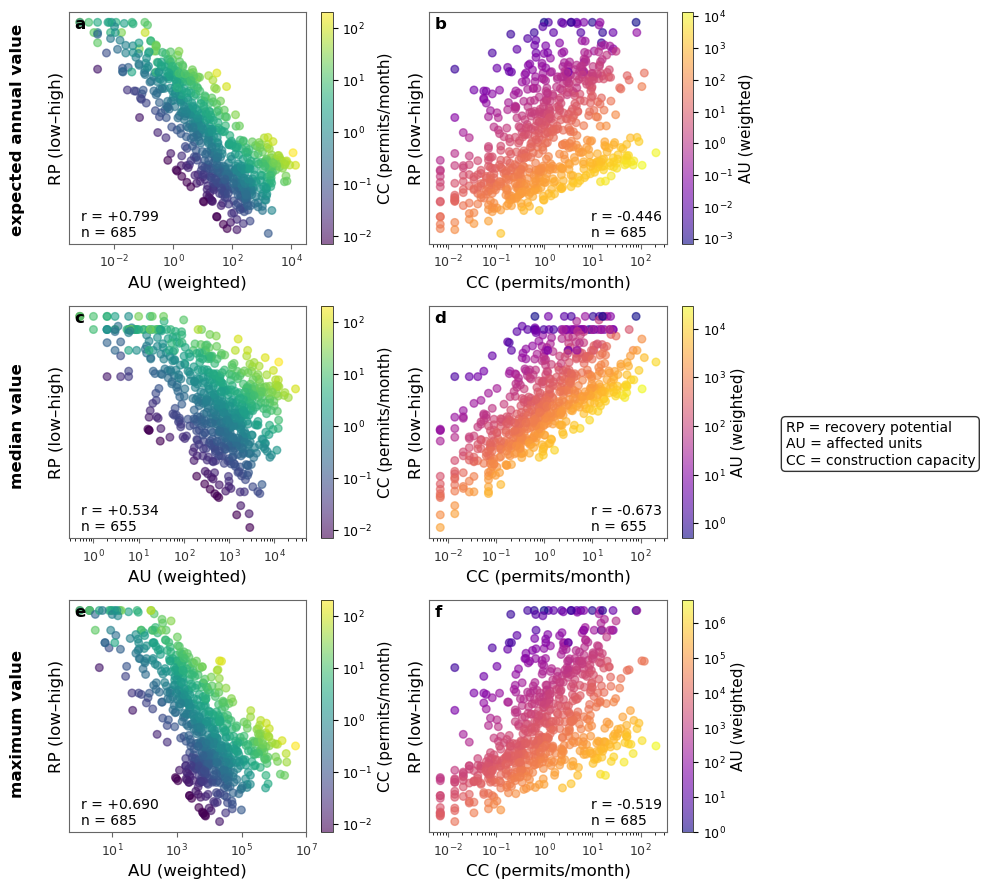

In [21]:
print("Creating recovery drivers scatterplot comparison...")

fig, axes = plt.subplots(3, 2, figsize=(8, 9))

label_fs = 12
tick_fs = 9
cbar_label_fs = 11

# ---------------- TOP LEFT: Annual damage vs EARP ----------------
ax1 = axes[0, 0]
scatter1 = ax1.scatter(
    annual_metrics['ead_weighted'], 
    annual_metrics['earp_months_per_year'],
    c=annual_metrics['construction_capacity'],
    cmap='viridis',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.set_xlabel('AU (weighted)', fontsize=label_fs)
ax1.set_ylabel('RP (low–high)', fontsize=label_fs)
ax1.grid(False)

cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('CC (permits/month)', fontsize=cbar_label_fs)
cbar1.ax.tick_params(which='both', labelsize=tick_fs)
cbar1.ax.tick_params(which='minor', length=0)

corr_annual_risk, _ = pearsonr(np.log10(annual_metrics['earp_months_per_year']), 
                                np.log10(annual_metrics['ead_weighted']))
ax1.text(0.05, 0.02, f'r = {corr_annual_risk:+.3f}\nn = {len(annual_metrics):,}', 
         transform=ax1.transAxes, fontsize=10, va='bottom')

# ---------------- TOP RIGHT: Capacity vs EARP ----------------
ax2 = axes[0, 1]
scatter2 = ax2.scatter(
    annual_metrics['construction_capacity'], 
    annual_metrics['earp_months_per_year'],
    c=annual_metrics['ead_weighted'],
    cmap='plasma',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.set_xlabel('CC (permits/month)', fontsize=label_fs)
ax2.set_ylabel('RP (low–high)', fontsize=label_fs)
ax2.grid(False)

cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('AU (weighted)', fontsize=cbar_label_fs)
cbar2.ax.tick_params(which='both', labelsize=tick_fs)
cbar2.ax.tick_params(which='minor', length=0)

corr_annual_capacity, _ = pearsonr(np.log10(annual_metrics['earp_months_per_year']), 
                                    np.log10(annual_metrics['construction_capacity']))
ax2.text(0.68, 0.02, f'r = {corr_annual_capacity:+.3f}\nn = {len(annual_metrics):,}', 
         transform=ax2.transAxes, fontsize=10, va='bottom')

# ---------------- MIDDLE LEFT: Median damage vs recovery ----------------
ax3 = axes[1, 0]
scatter3 = ax3.scatter(
    median_metrics['median_weighted_damage'], 
    median_metrics['median_recovery_months'],
    c=median_metrics['construction_capacity'],
    cmap='viridis',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.set_xlabel('AU (weighted)', fontsize=label_fs)
ax3.set_ylabel('RP (low–high)', fontsize=label_fs)
ax3.grid(False)

cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('CC (permits/month)', fontsize=cbar_label_fs)
cbar3.ax.tick_params(which='both', labelsize=tick_fs)
cbar3.ax.tick_params(which='minor', length=0)

corr_median_damage, _ = pearsonr(np.log10(median_metrics['median_recovery_months']), 
                                  np.log10(median_metrics['median_weighted_damage']))
ax3.text(0.05, 0.02, f'r = {corr_median_damage:+.3f}\nn = {len(median_metrics):,}', 
         transform=ax3.transAxes, fontsize=10, va='bottom')

# ---------------- MIDDLE RIGHT: Capacity vs Median recovery ----------------
ax4 = axes[1, 1]
scatter4 = ax4.scatter(
    median_metrics['construction_capacity'], 
    median_metrics['median_recovery_months'],
    c=median_metrics['median_weighted_damage'],
    cmap='plasma',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.invert_yaxis()
ax4.set_xlabel('CC (permits/month)', fontsize=label_fs)
ax4.set_ylabel('RP (low–high)', fontsize=label_fs)
ax4.grid(False)

cbar4 = plt.colorbar(scatter4, ax=ax4)
cbar4.set_label('AU (weighted)', fontsize=cbar_label_fs)
cbar4.ax.tick_params(which='both', labelsize=tick_fs)
cbar4.ax.tick_params(which='minor', length=0)

corr_median_capacity, _ = pearsonr(np.log10(median_metrics['median_recovery_months']), 
                                    np.log10(median_metrics['construction_capacity']))
ax4.text(0.68, 0.02, f'r = {corr_median_capacity:+.3f}\nn = {len(median_metrics):,}', 
         transform=ax4.transAxes, fontsize=10, va='bottom')

# ---------------- BOTTOM LEFT: Max damage vs recovery ----------------
ax5 = axes[2, 0]
scatter5 = ax5.scatter(
    max_metrics['max_weighted_damage'], 
    max_metrics['max_recovery_months'],
    c=max_metrics['construction_capacity'],
    cmap='viridis',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.set_xlabel('AU (weighted)', fontsize=label_fs)
ax5.set_ylabel('RP (low–high)', fontsize=label_fs)
ax5.grid(False)

cbar5 = plt.colorbar(scatter5, ax=ax5)
cbar5.set_label('CC (permits/month)', fontsize=cbar_label_fs)
cbar5.ax.tick_params(which='both', labelsize=tick_fs)
cbar5.ax.tick_params(which='minor', length=0)

corr_max_damage, _ = pearsonr(np.log10(max_metrics['max_recovery_months']), 
                               np.log10(max_metrics['max_weighted_damage']))
ax5.text(0.05, 0.02, f'r = {corr_max_damage:+.3f}\nn = {len(max_metrics):,}', 
         transform=ax5.transAxes, fontsize=10, va='bottom')

# ---------------- BOTTOM RIGHT: Capacity vs Max recovery ----------------
ax6 = axes[2, 1]
scatter6 = ax6.scatter(
    max_metrics['construction_capacity'], 
    max_metrics['max_recovery_months'],
    c=max_metrics['max_weighted_damage'],
    cmap='plasma',
    alpha=0.6,
    s=30,
    norm=LogNorm()
)
ax6.set_xscale('log')
ax6.set_yscale('log')
ax6.invert_yaxis()
ax6.set_xlabel('CC (permits/month)', fontsize=label_fs)
ax6.set_ylabel('RP (low–high)', fontsize=label_fs)
ax6.grid(False)

cbar6 = plt.colorbar(scatter6, ax=ax6)
cbar6.set_label('AU (weighted)', fontsize=cbar_label_fs)
cbar6.ax.tick_params(which='both', labelsize=tick_fs)
cbar6.ax.tick_params(which='minor', length=0)

corr_max_capacity, _ = pearsonr(np.log10(max_metrics['max_recovery_months']), 
                                 np.log10(max_metrics['construction_capacity']))
ax6.text(0.68, 0.02, f'r = {corr_max_capacity:+.3f}\nn = {len(max_metrics):,}', 
         transform=ax6.transAxes, fontsize=10, va='bottom')

# Formatting all colorbars and axes
for cbar in [cbar1, cbar2, cbar3, cbar4, cbar5, cbar6]:
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    for spine in ax.spines.values():
        spine.set_edgecolor('0.4')
        spine.set_linewidth(0.8)
    ax.tick_params(color='0.4', labelcolor='0.2')

# Panel labels
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f']
for label, ax in zip(panel_labels, [ax1, ax2, ax3, ax4, ax5, ax6]):
    ax.text(0.02, 0.98, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# Axis ticks
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.tick_params(axis='x', which='major', bottom=True, top=False,
                   labelbottom=True, labelsize=tick_fs)
    ax.tick_params(axis='y', which='both', left=False, right=False,
                   labelleft=False)

# Add row labels on the left
fig.text(0.02, 0.85, 'expected annual value', rotation=90, va='center', ha='center', 
         fontsize=12, fontweight='bold')
fig.text(0.02, 0.52, 'median value', rotation=90, va='center', ha='center', 
         fontsize=12, fontweight='bold')
fig.text(0.02, 0.19, 'maximum value', rotation=90, va='center', ha='center', 
         fontsize=12, fontweight='bold')

# Add legend on the right side, middle row
legend_text = 'RP = recovery potential\nAU = affected units\nCC = construction capacity'
fig.text(0.98, 0.50, legend_text, va='center', ha='left', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout(rect=[0.04, 0, 0.96, 1])
plt.savefig(OUTPUT_DIR / "recovery_drivers_annual_vs_median_vs_max.png", dpi=300, bbox_inches="tight")
print("✓ Saved: recovery_drivers_annual_vs_median_vs_max.png")
plt.show()
plt.close()


## Figure: Skewness Spatial Map

In [22]:
# Load distribution metrics
print("Loading distribution metrics for skewness map...")
county_dist = pd.read_csv(OUTPUT_DIR / 'county_distribution_metrics.csv')
county_dist['fips'] = county_dist['fips'].astype(str).str.zfill(5)

# Use coastal counties only (same 19 states as other analyses)
# Merge with distribution data
gdf = coastal_counties.merge(county_dist, left_on='GEOID', right_on='fips', how='left')

print(f"Counties with distribution data: {gdf['tail_dominance'].notna().sum()}")

Loading distribution metrics for skewness map...
Counties with distribution data: 742


Creating skewness spatial map...
✓ Saved: skewness_maps.png


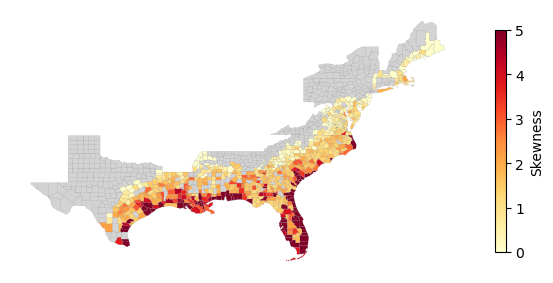

In [23]:
print("Creating skewness spatial map...")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot counties with data
gdf.plot(
    column='rt_skew',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    vmin=0,
    vmax=5,
    linewidth=0.1,
    edgecolor="0.5",
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "0.5"
    },
    legend_kwds={'label': 'Skewness', 'shrink': 0.6}
)

ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skewness_maps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: skewness_maps.png")
plt.show()
plt.close()


## Figure: Quadrant Analysis - Scatter Comparison

In [24]:
# Load quadrant data
print("Loading quadrant analysis data...")
df_abs = pd.read_csv(OUTPUT_DIR / 'event_county_quadrants_weightedunits.csv')
df_norm = pd.read_csv(OUTPUT_DIR / 'event_county_quadrants_fully_normalized.csv')

print(f"Absolute data: {len(df_abs):,} event-county pairs")
print(f"Normalized data: {len(df_norm):,} event-county pairs")

Loading quadrant analysis data...
Absolute data: 27,060 event-county pairs
Normalized data: 27,060 event-county pairs


Creating scatter comparison: absolute vs normalized...


✓ Saved: scatter_comparison_absolute_vs_normalized.png


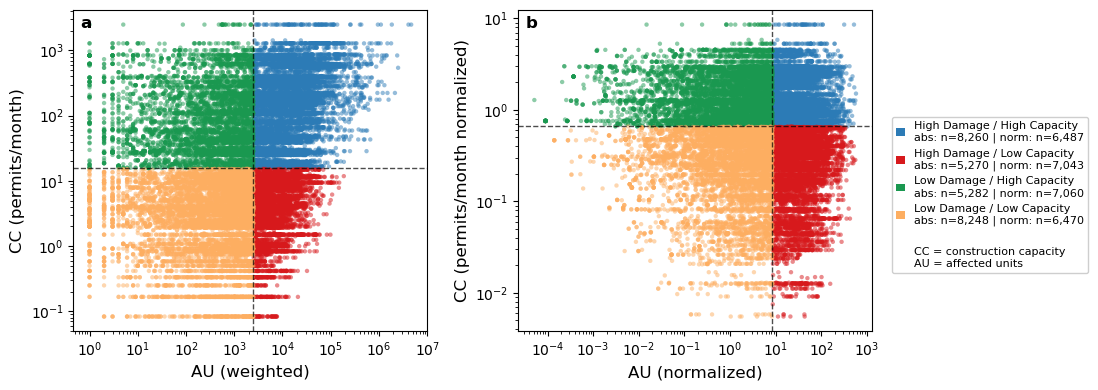

In [25]:
print("Creating scatter comparison: absolute vs normalized...")

# Color scheme
quadrant_colors = {
    'High Damage / High Capacity': '#2c7bb6',
    'High Damage / Low Capacity': '#d7191c',
    'Low Damage / High Capacity': '#1a9850',
    'Low Damage / Low Capacity': '#fdae61'
}

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel A: Absolute analysis
ax = axes[0]
for quadrant, color in quadrant_colors.items():
    subset = df_abs[df_abs['quadrant'] == quadrant]
    ax.scatter(subset['weighted_damage_units'], subset['construction_capacity'],
               alpha=0.5, s=10, c=color,
               edgecolors='none')

# Add median threshold lines
abs_median_damage = df_abs['weighted_damage_units'].median()
abs_median_capacity = df_abs['construction_capacity'].median()
ax.axvline(abs_median_damage, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(abs_median_capacity, color='black', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('AU (weighted)', fontsize=12)
ax.set_ylabel('CC (permits/month)', fontsize=12)
ax.grid(False)

# Add panel label
ax.text(0.02, 0.98, 'a', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

# Panel B: Normalized analysis
ax = axes[1]
for quadrant, color in quadrant_colors.items():
    subset = df_norm[df_norm['quadrant'] == quadrant]
    ax.scatter(subset['pct_housing_damaged'], subset['capacity_per_1000_units'],
               alpha=0.5, s=10, c=color,
               edgecolors='none')

# Add median threshold lines
norm_median_damage = df_norm['pct_housing_damaged'].median()
norm_median_capacity = df_norm['capacity_per_1000_units'].median()
ax.axvline(norm_median_damage, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(norm_median_capacity, color='black', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('AU (normalized)', fontsize=12)
ax.set_ylabel('CC (permits/month normalized)', fontsize=12)
ax.grid(False)

# Add panel label
ax.text(0.02, 0.98, 'b', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

# Create shared legend with counts from both datasets
from matplotlib.patches import Patch
legend_elements = []
for quadrant, color in quadrant_colors.items():
    count_abs = len(df_abs[df_abs['quadrant'] == quadrant])
    count_norm = len(df_norm[df_norm['quadrant'] == quadrant])
    legend_elements.append(
        Patch(facecolor=color, edgecolor='none', 
              label=f'{quadrant}\nabs: n={count_abs:,} | norm: n={count_norm:,}')
    )

# Add separator and definitions
legend_elements.append(Patch(facecolor='none', edgecolor='none', label=''))
legend_elements.append(Patch(facecolor='none', edgecolor='none', 
                             label='CC = construction capacity\nAU = affected units'))

fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.99, 0.5), 
           fontsize=8, framealpha=0.95, handlelength=0.8)

plt.tight_layout()
#plt.subplots_adjust(right=0.90)
plt.savefig(OUTPUT_DIR / 'scatter_comparison_absolute_vs_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: scatter_comparison_absolute_vs_normalized.png")
plt.show()
plt.close()


## Figure: Dominant Quadrant Map

In [26]:
# Calculate dominant quadrants for both approaches
print("Calculating dominant quadrants...")

def calculate_dominant_quadrants(df):
    """Calculate the most common quadrant for each county."""
    county_quadrants = []
    for fips in df['fips'].unique():
        county_data = df[df['fips'] == fips]
        quadrant_counts = Counter(county_data['quadrant'])
        dominant_quadrant = quadrant_counts.most_common(1)[0][0]
        frequency = quadrant_counts.most_common(1)[0][1]
        total_events = len(county_data)
        
        county_quadrants.append({
            'fips': fips,
            'dominant_quadrant': dominant_quadrant,
            'frequency': frequency,
            'total_events': total_events,
            'dominance_pct': 100 * frequency / total_events
        })
    return pd.DataFrame(county_quadrants)

county_df_abs = calculate_dominant_quadrants(df_abs)
county_df_norm = calculate_dominant_quadrants(df_norm)

print(f"Computed dominant quadrants for {len(county_df_abs)} counties (absolute)")
print(f"Computed dominant quadrants for {len(county_df_norm)} counties (normalized)")

Calculating dominant quadrants...
Computed dominant quadrants for 685 counties (absolute)
Computed dominant quadrants for 685 counties (normalized)


In [27]:
# Prepare spatial data
county_df_abs['fips'] = county_df_abs['fips'].astype(str).str.zfill(5)
county_df_norm['fips'] = county_df_norm['fips'].astype(str).str.zfill(5)

# Merge with coastal counties
counties_abs = coastal_counties.merge(county_df_abs, left_on='GEOID', right_on='fips', how='left')
counties_norm = coastal_counties.merge(county_df_norm, left_on='GEOID', right_on='fips', how='left')

print("Spatial data prepared for mapping")

Spatial data prepared for mapping


Creating dominant quadrant comparison map...
✓ Saved: dominant_quadrant_comparison_map.png


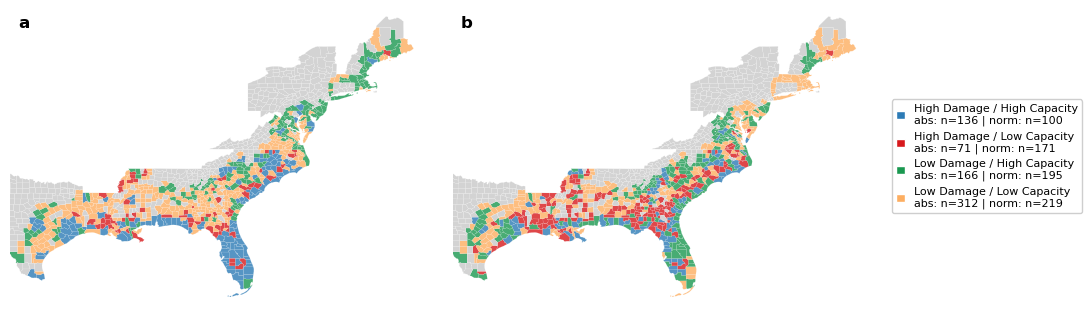

In [28]:
print("Creating dominant quadrant comparison map...")

# Define colors
colors = {
    'High Damage / High Capacity': '#2c7bb6',  # blue
    'High Damage / Low Capacity': '#d7191c',  # red - Critical
    'Low Damage / High Capacity': '#1a9850',  # green
    'Low Damage / Low Capacity': '#fdae61'  # orange
}

# Create side-by-side maps
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left panel: Absolute
ax = axes[0]
legend_elements = []

for quadrant, color in colors.items():
    subset = counties_abs[counties_abs['dominant_quadrant'] == quadrant]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.1, alpha=0.8)

no_data = counties_abs[counties_abs['dominant_quadrant'].isna()]
if len(no_data) > 0:
    no_data.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.1)
ax.set_xlim(-100, -65)
ax.set_ylim(24, 48)
ax.set_aspect('equal')
ax.axis('off')

# Add panel label
ax.text(0.02, 0.98, 'a', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

# Right panel: Fully normalized
ax = axes[1]

for quadrant, color in colors.items():
    subset_abs = counties_abs[counties_abs['dominant_quadrant'] == quadrant]
    subset_norm = counties_norm[counties_norm['dominant_quadrant'] == quadrant]
    if len(subset_norm) > 0:
        subset_norm.plot(ax=ax, color=color, edgecolor='white', linewidth=0.1, alpha=0.8)
        count_abs = len(subset_abs)
        count_norm = len(subset_norm)
        legend_elements.append(Patch(facecolor=color, edgecolor='white', 
                                     label=f'{quadrant}\nabs: n={count_abs} | norm: n={count_norm}'))

no_data = counties_norm[counties_norm['dominant_quadrant'].isna()]
if len(no_data) > 0:
    no_data.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.1)

ax.set_xlim(-100, -65)
ax.set_ylim(24, 48)
ax.set_aspect('equal')
ax.axis('off')

# Add panel label
ax.text(0.02, 0.98, 'b', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

# Add legend on the right side of the figure
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.99, 0.5), 
           fontsize=8, framealpha=0.95, handlelength=0.8)

# Save
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dominant_quadrant_comparison_map.png', dpi=300, bbox_inches='tight')
print("✓ Saved: dominant_quadrant_comparison_map.png")
plt.show()
plt.close()

# 8. Single Event Analysis: Contrasting Damage vs Recovery

This section analyzes individual hurricane events to demonstrate that:
1. **High damage ≠ High recovery burden** - Counties with similar damage can have vastly different recovery times
2. **Rankings matter** - Counties ranked by damage differ substantially from those ranked by recovery potential
3. **Capacity drives divergence** - Construction capacity differentiates recovery outcomes even when damage is similar

We examine two contrasting events:
- **Event 4347**: Large spatial extent (FL/SC/NC), high absolute damage, moderate capacity stress
- **Event 350**: Different damage pattern and capacity constraints

For each event, we show:
- 3-panel spatial maps (Damage | Capacity | Recovery)
- County rankings by damage vs recovery (absolute and normalized)
- Rank dissimilarity analysis

## Figure: 3-Panel Maps for Selected Events

Generate spatial maps matching the style of earlier figures (no titles, panel labels a/b/c, matching colorbars).

In [39]:
# Selected events for spatial analysis
SELECTED_EVENTS = ['4347', '350']

print("Preparing to create 3-panel maps for selected events...")
print(f"Events to analyze: {', '.join(SELECTED_EVENTS)}\n")

# Prepare data for each event
event_spatial_data = {}

for event_id in SELECTED_EVENTS:
    print(f"Preparing event {event_id}...")
    
    # Filter event damage data
    event_damage = events_df[events_df['event_name'] == event_id].copy()
    
    if len(event_damage) == 0:
        print(f"  ⚠ No damage data found")
        continue
    
    # Calculate total damage units (weighted)
    event_damage['total_damage_units'] = (
        event_damage['units_DS1_scaled'] * RECOVERY_WEIGHTS['DS1'] +
        event_damage['units_DS2_scaled'] * RECOVERY_WEIGHTS['DS2'] +
        event_damage['units_DS3_scaled'] * RECOVERY_WEIGHTS['DS3'] +
        event_damage['units_DS4_scaled'] * RECOVERY_WEIGHTS['DS4']
    )
    
    # Get damaged county fips codes for this event
    damaged_fips = event_damage['fips'].unique()
    
    # Load recovery data for this specific event from JSON file
    recovery_file = DATA_DIR / "recovery_potential_per_scenario" / f"{event_id}_scaled_recovery_potential.json"
    with open(recovery_file, 'r') as f:
        event_recovery_data = json.load(f)
    event_recovery = pd.DataFrame(event_recovery_data)
    event_recovery['fips'] = event_recovery['fips'].astype(str).str.zfill(5)
    
    # Check for duplicates in recovery data
    if event_recovery['fips'].duplicated().any():
        print(f"  ⚠ WARNING: Recovery data has duplicate FIPS codes!")
        print(f"    Duplicates: {event_recovery[event_recovery['fips'].duplicated(keep=False)]['fips'].unique()}")
    
    # Merge damage with capacity FIRST (one-to-one merge)
    event_data = event_damage[['fips', 'total_damage_units']].merge(
        capacity_df[['fips', 'construction_capacity']], on='fips', how='left'
    )
    
    # Then merge with recovery data
    event_data = event_data.merge(
        event_recovery[['fips', 'recovery_potential [months]']], on='fips', how='left'
    )
    
    event_data = event_data.rename(columns={'recovery_potential [months]': 'recovery_months'})
    event_data = event_data[event_data['total_damage_units'] > 0]
    
    # DIAGNOSTIC: Check Lee County (FIPS typically 12071 for Lee County, FL)
    lee_counties = event_data[event_data['fips'].str.contains('071', na=False)]
    if len(lee_counties) > 0:
        print(f"  DEBUG: Lee County entries in event {event_id}:")
        for idx, row in lee_counties.iterrows():
            print(f"    FIPS {row['fips']}: capacity={row['construction_capacity']:.2f}, damage={row['total_damage_units']:.1f}, recovery={row['recovery_months']:.1f}")
    
    event_spatial_data[event_id] = event_data
    
    print(f"  Counties: {len(event_data)}")
    print(f"  Total damage: {event_data['total_damage_units'].sum():,.0f} units")
    print(f"  Median recovery: {event_data['recovery_months'].median():.1f} months\n")

print(f"✓ Prepared {len(event_spatial_data)} events for mapping")

Preparing to create 3-panel maps for selected events...
Events to analyze: 4347, 350

Preparing event 4347...
  Counties: 64
  Total damage: 6,523,456 units
  Median recovery: 372.0 months

Preparing event 350...
  DEBUG: Lee County entries in event 350:
    FIPS 12071: capacity=107.02, damage=166379.0, recovery=129.6
  Counties: 56
  Total damage: 3,670,675 units
  Median recovery: 348.4 months

✓ Prepared 2 events for mapping


In [40]:
# Diagnostic: Check capacity data merge quality
print("DIAGNOSTIC: Checking capacity data merge...")
print(f"\nTotal counties in capacity_df: {len(capacity_df)}")
print(f"Sample capacity_df fips: {capacity_df['fips'].head().tolist()}")

for event_id in SELECTED_EVENTS:
    if event_id in event_spatial_data:
        event_data = event_spatial_data[event_id]
        n_total = len(event_data)
        n_with_capacity = event_data['construction_capacity'].notna().sum()
        n_missing_capacity = event_data['construction_capacity'].isna().sum()
        n_zero_capacity = (event_data['construction_capacity'] == 0).sum()
        
        print(f"\nEvent {event_id}:")
        print(f"  Total counties: {n_total}")
        print(f"  Counties WITH capacity data: {n_with_capacity}")
        print(f"  Counties MISSING capacity data: {n_missing_capacity}")
        print(f"  Counties with ZERO capacity: {n_zero_capacity}")
        
        if n_missing_capacity > 0:
            missing_fips = event_data[event_data['construction_capacity'].isna()]['fips'].head(5).tolist()
            print(f"  Sample FIPS with missing capacity: {missing_fips}")
            
            # Check if these fips exist in capacity_df
            for fips in missing_fips[:3]:
                in_capacity = fips in capacity_df['fips'].values
                print(f"    {fips} in capacity_df: {in_capacity}")

DIAGNOSTIC: Checking capacity data merge...

Total counties in capacity_df: 1203
Sample capacity_df fips: ['01001', '01003', '01005', '01007', '01009']

Event 4347:
  Total counties: 64
  Counties WITH capacity data: 64
  Counties MISSING capacity data: 0
  Counties with ZERO capacity: 0

Event 350:
  Total counties: 56
  Counties WITH capacity data: 56
  Counties MISSING capacity data: 0
  Counties with ZERO capacity: 1



Creating 3-panel map for event 4347...
✓ Saved: event_4347_3panel_map.png


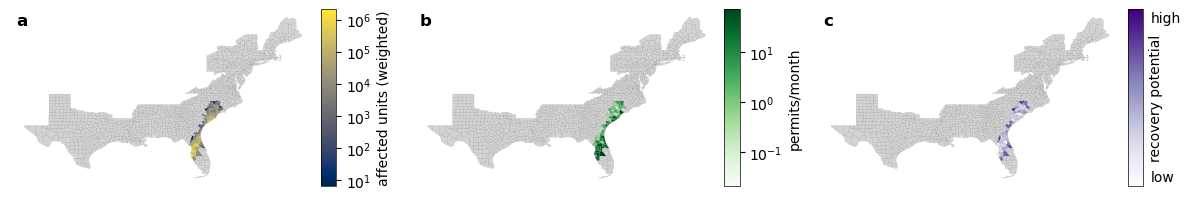


Creating 3-panel map for event 350...
✓ Saved: event_350_3panel_map.png


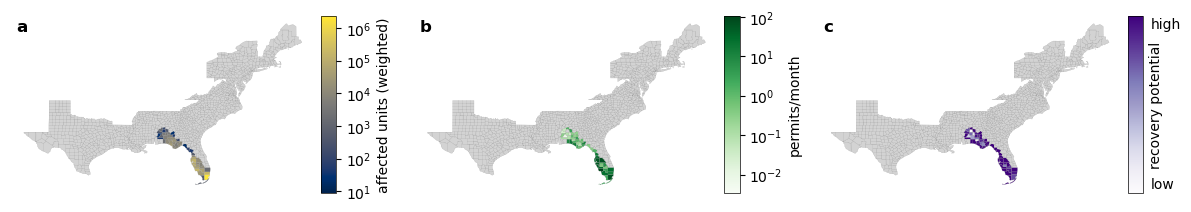


✓ All event maps created!


In [41]:
# Create 3-panel maps for each event
for event_id, event_data in event_spatial_data.items():
    print(f"\nCreating 3-panel map for event {event_id}...")
    
    # Merge with geometries
    gdf = coastal_counties.merge(
        event_data[['fips', 'total_damage_units', 'construction_capacity', 'recovery_months']],
        left_on='GEOID',
        right_on='fips',
        how='left'
    )
    
    # Replace zeros/negatives with NaN
    gdf_plot = gdf.copy()
    for col in ['total_damage_units', 'construction_capacity', 'recovery_months']:
        gdf_plot.loc[gdf_plot[col] <= 0, col] = np.nan
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Metrics: (column, cmap, ylabel)
    metrics = [
        ('total_damage_units', 'cividis', 'affected units (weighted)'),
        ('construction_capacity', 'Greens', 'permits/month'),
        ('recovery_months', 'Purples_r', 'recovery potential')
    ]

    subplot_labels = ['a', 'b', 'c']
    
    for idx, (ax, (column, cmap, ylabel)) in enumerate(zip(axes, metrics)):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        
        data = gdf_plot[column].dropna()
        
        if len(data) > 0:
            vmin = data.min()
            vmax = data.max()
            
            # Check if valid for LogNorm
            if np.isfinite(vmin) and np.isfinite(vmax) and vmin > 0 and vmax > 0:
                log_vmin = vmin / 2
                norm = LogNorm(vmin=log_vmin, vmax=vmax)
            else:
                norm = None
            
            gdf_plot.plot(
                column=column,
                cmap=cmap,
                linewidth=0.1,
                edgecolor='0.5',
                legend=True,
                ax=ax,
                cax=cax,
                norm=norm,
                missing_kwds={"color": "lightgrey", "edgecolor": "0.5"}
            )
            
            ax.axis("off")
            ax.text(0.02, 0.98, subplot_labels[idx], transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='top', ha='left')
            
            # Colorbar formatting
            if 'recovery' in column:
                cax.invert_yaxis()
                cax.yaxis.set_major_locator(NullLocator())
                cax.yaxis.set_minor_locator(NullLocator())
                cax.tick_params(which='both', left=False, right=False, labelleft=False)
                cax.text(1.5, 0.99, 'high', transform=cax.transAxes, 
                        fontsize=10, va='top', ha='left')
                cax.text(1.5, 0.01, 'low', transform=cax.transAxes, 
                        fontsize=10, va='bottom', ha='left')
                cax.set_ylabel(ylabel, fontsize=10)
            else:
                cax.set_ylabel(ylabel, fontsize=10)
                cax.tick_params(labelsize=10, which='minor', length=0)
            
            for spine in cax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(0.5)
    
    plt.tight_layout()
    output_file = OUTPUT_DIR / f'event_{event_id}_3panel_map.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_file.name}")
    plt.show()
    plt.close()

print("\n✓ All event maps created!")

In [42]:
event_spatial_data

{'4347':      fips  total_damage_units  construction_capacity  recovery_months
 0   37007              1807.0               0.381944       394.254545
 1   37017               144.0               1.104167        10.867925
 3   37047              1463.0               0.166667       731.500000
 4   37051              1474.0               7.812500        15.722667
 5   37085              2657.0              14.444444        15.328846
 ..    ...                 ...                    ...              ...
 67  13049               693.0               0.340278       169.714286
 68  13051               746.0              18.708333         6.000000
 69  13127              4377.0               5.097222        71.558583
 70  13179               343.0               3.270833         8.738854
 71  13191              4441.0               0.881944       419.622047
 
 [64 rows x 4 columns],
 '350':      fips  total_damage_units  construction_capacity  recovery_months
 0   13087               144.0      